In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("C:/Datasets/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
col_list = ["Glucose", "BloodPressure", "SkinThickness", "BMI", "Insulin"]
for i in col_list:
    df[i] = df[i].replace(0, np.nan)
    mean = int(df[i].mean(skipna = True))
    df[i] = df[i].replace(np.nan, mean)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,155.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,155.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,155.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,155.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,155.0,30.1,0.349,47,1


In [5]:
x = df.iloc[:, :8]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,155.0,33.6,0.627,50
1,1,85.0,66.0,29.0,155.0,26.6,0.351,31
2,8,183.0,64.0,29.0,155.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63
764,2,122.0,70.0,27.0,155.0,36.8,0.340,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
766,1,126.0,60.0,29.0,155.0,30.1,0.349,47


In [6]:
y = df.iloc[:, 8]
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

In [8]:
k_range = range(1, 20)
scores = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(x_train, y_train)
    accuracy = model.score(x_test, y_test)
    scores.append(accuracy)
    print(scores)

[0.6558441558441559]
[0.6558441558441559, 0.7207792207792207]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663, 0.7532467532467533]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663, 0.7532467532467533, 0.7662337662337663]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663, 0.7532467532467533, 0.7662337662337663, 0.7597402597402597]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663, 0.7532467532467533, 0.7662337662337663, 0.7597402597402597, 0.7662337662337663]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663, 0.7532467532467533, 0.7662337662337663, 0.7597402597402597, 0.7662337662337663, 0.7532467532467533]
[0.6558441558441559, 0.7207792207792207, 0.7272727272727273, 0.7662337662337663, 0.75324675

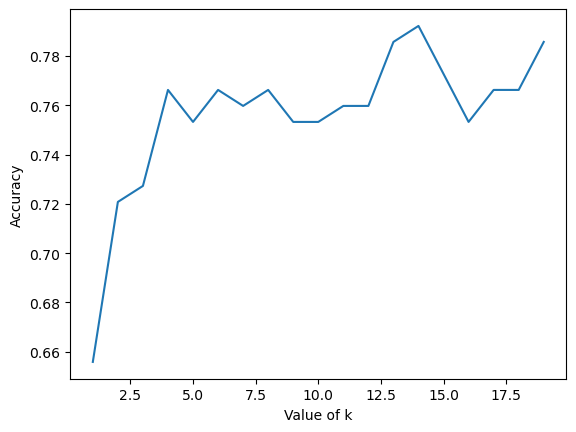

In [9]:
import matplotlib.pyplot as plt
plt.plot(k_range, scores)
plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.show()

In [10]:
model = KNeighborsClassifier(n_neighbors = 14, metric = "euclidean")
model.fit(x_train, y_train)

,n_neighbors,14
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [11]:
accuracy = model.score(x_test, y_test)
accuracy

0.7922077922077922

In [12]:
model.predict([[1, 189, 60, 23, 846, 30.1, 0.398, 59]])

c:\Users\MOHIT SINGH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])

In [13]:
model.predict([[1, 126, 88, 41, 235, 39.3, 0.704, 27]])

c:\Users\MOHIT SINGH\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])